In [65]:
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict,Annotated,Literal
from dotenv import load_dotenv
from pydantic import BaseModel,Field
from langchain_core.messages import SystemMessage,HumanMessage
import operator


In [66]:
generator_llm = ChatGoogleGenerativeAI(
    model="models/gemini-3-flash-preview"
)

evaluator_llm = ChatGoogleGenerativeAI(
    model="models/gemini-3-flash-preview"
)

optimizer_llm = ChatGoogleGenerativeAI(
    model="models/gemini-3-flash-preview"
)


In [67]:
class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [68]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [69]:
class TweetState(TypedDict):

    topic: str
    tweet: str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str
    iteration: int
    max_iteration: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [70]:
def generate_tweet(state: TweetState):

    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    # send generator_llm
    response = generator_llm.invoke(messages).content

    # return response
    return {'tweet': response, 'tweet_history': [response]}

In [71]:
def evaluate_tweet(state: TweetState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [72]:
def optimize_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [73]:
def route_evaluation(state: TweetState):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

In [74]:
def optimize_tweet(state: TweetState):

    messages = [
        SystemMessage(content="Improve tweet for virality."),
        HumanMessage(content=f"""
Topic: {state['topic']}
Tweet: {state['tweet']}
Feedback: {state['feedback']}

Rewrite improved tweet under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content

    return {
        "tweet": response,
        "iteration": state["iteration"] + 1
    }


In [75]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')

graph.add_conditional_edges('evaluate', route_evaluation, {'approved': END, 'needs_improvement': 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()


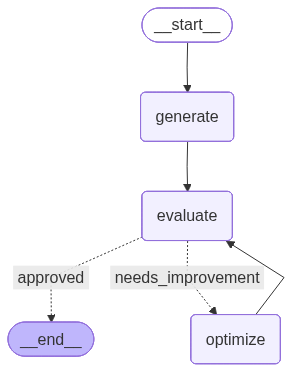

In [76]:
workflow

In [77]:
initial_state = {
    "topic": "cricket",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

ChatGoogleGenerativeAIError: Error calling model 'models/gemini-3-flash-preview' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3-flash\nPlease retry in 6.403235305s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerM

In [ ]:
result

{'topic': 'srhberhb', 'tweet': [{'type': 'text', 'text': 'There is no English word for that specific level of “done” where you just stare at your screen and type “srhberhb” into the Slack channel. It’s not a typo, it’s a spiritual resignation.', 'extras': {'signature': 'EqMTCqATAb4+9vt9L9/QAv6c4NBWvHyji7O9ULLNI2rWRXLzVFj5WCEcg2Y/k9XZ+kE1ohLQygvjTqsHICFus7CbuDVWozOyLh+5UzEh7O2/atgAaZgJvEiaaiuALzsDE7fk1ZF8fP0u0gJUBs32Z1JwR4kENuAfqB9yzBxn8+6WRmwvVa57gljnv9wkXMN/raEVBBsou3QV8U4hh0euUsasTNkZO+eCMbBSofJsvQvd5Gn/vZqRB26hW3yZo7E0qA8XyjtsvtgR++CKZWLTEyzOTccGfYBx00gc/3dhnL/A9K3Q+B+qx5/IfFUsn826TuaHUr4rofyWar4SPkjOfw2+IURNhl/HcSCaTDUKgtthsDBKYPQpqDYJoZw8Nss0S/gc1Wm10Fr2SSsphfuVxhS7GD9p1Dcgf1okZCxuQKH1w1twWa2iV/p2mpn2P7+Vh3sKSyC5vWPdxVXEU9m/Z67xJXP2++AqNQkp9LCvTnelHKqqEzb65U+ltTi65TCVp7ItS5sX0+K/ls7wTVNZrRb2Oz7d3p+aoLryP6/aMrgTChN2jBClLQIno9NyO97bTFlBG9ve8UY7tTEHDJqpU3CEyPw7ow9wZZbySde0t6qE8io2rfuPBy4RWY8g1T1FCu/9MfuQR1NJVCMc0QSubrx3Bj1C+bvohrCET7St9hKsxoKEHS+wx+fXINiGd6BI3jdRIbI5wqDJ5S83llKr30XwQ